## Quick start
After cloning the repository, the package may be installed with `pip` in the regular way. From the repository root run:

```bash
pip install .
```

The following code plots density slices from the bundled local spherical and Cartesian 3D sample files.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from batread import Dataset

from batcamp import OctreeInterpolator


## Plot bundled solar corona (SC) sample data
This bundled 3D sample uses a spherical octree structure.


Title:     'BATSRUS: 3D Data, 2000/01/30 00:00:01.000'
Zone:      '3D   N=0060005'
Variables: 4
Shape:     (22016, 4)
Variables: ['X [R]', 'Y [R]', 'Z [R]', 'Rho [g/cm^3]'].


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


OctreeInterpolator(tree_coord=rpa, fields=1[Rho [g/cm^3]], n_points=22016, n_cells=19968, n_components=1)


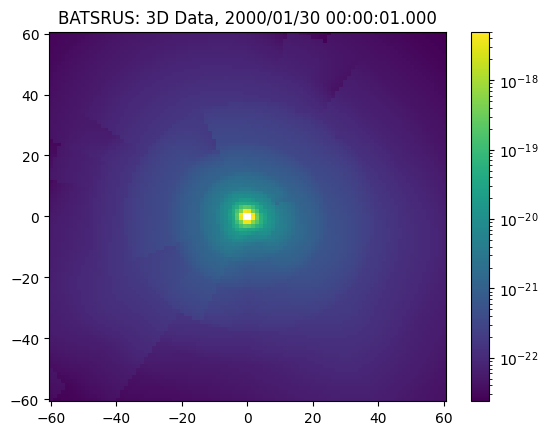

In [2]:
ds = Dataset.from_file("../sample_data/3d__var_2_n00060005.plt")
print(ds)

interp = OctreeInterpolator(ds, ["Rho [g/cm^3]"])
print(interp)

X, Y = np.meshgrid(np.linspace(-60, 60, 100), np.linspace(-60, 60, 100))
Z = np.zeros_like(X)
rho = interp(X, Y, Z)

fig, ax = plt.subplots()
pcm = ax.pcolormesh(X, Y, rho, norm="log")
fig.colorbar(pcm, ax=ax)
ax.set_title(ds.title)
plt.show()


## Plot bundled inner heliosphere (IH) sample data
This bundled 3D sample uses a Cartesian octree structure.


Title:     'BATSRUS: 3D Data, 2000/01/30 00:00:00.000'
Zone:      '3D   N=0006003'
Variables: 4
Shape:     (21069, 4)
Variables: ['X [R]', 'Y [R]', 'Z [R]', 'Rho [g/cm^3]'].


OctreeInterpolator(tree_coord=xyz, fields=1[Rho [g/cm^3]], n_points=21069, n_cells=18432, n_components=1)


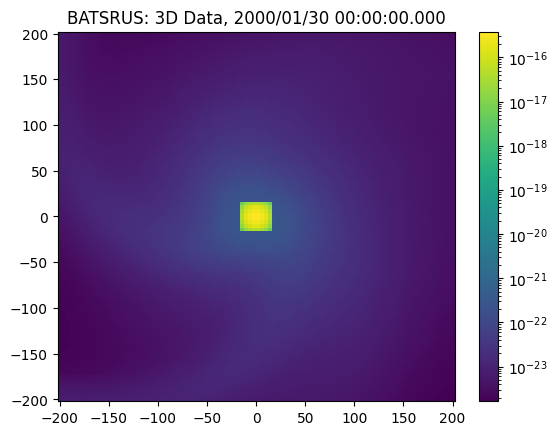

In [3]:
ds = Dataset.from_file("../sample_data/3d__var_2_n00006003.plt")
print(ds)

interp = OctreeInterpolator(ds, ["Rho [g/cm^3]"])
print(interp)

X, Y = np.meshgrid(np.linspace(-200, 200, 100), np.linspace(-200, 200, 100))
Z = np.zeros_like(X)
rho = interp(X, Y, Z)

fig, ax = plt.subplots()
pcm = ax.pcolormesh(X, Y, rho, norm="log")
fig.colorbar(pcm, ax=ax)
ax.set_title(ds.title)
plt.show()
